# Telco Customer Churn Intelligence

## Project Overview

This project analyzes customer behavior and service usage data from a telecommunications company to understand customer churn patterns and identify factors associated with customer retention.

The analysis combines data cleaning, exploratory data analysis, feature engineering, and predictive modeling to generate actionable business insights.

# Business Questions

This analysis aims to answer:

1. Which customer groups are more likely to churn?

2. How do contract type, tenure, and monthly charges influence customer churn?

3. Which services are most strongly associated with customer retention?

4. What customer characteristics appear to be the strongest predictors of churn?

5. Can customer churn be predicted using machine learning models?

6. What business actions could help reduce customer churn and improve customer retention?


## Dataset Information

Source: IBM Telco Customer Churn Dataset

Records: 7,043 customers

Features: 33 variables

Target Variable: Churn Label

## Skills Demonstrated

- Data loading and exploration using Pandas
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization with Matplotlib and Seaborn
- Feature engineering and transformation
- Customer churn analysis
- Correlation and business insight generation
- Classification modeling with Scikit-Learn
- Model evaluation and performance comparison
- Business recommendations based on analytical findings

# 1. Import Libraries
The required Python libraries are imported for data manipulation, numeric operations, and data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Data Loading
In this section, the customer churn dataset is loaded as the raw dataset.

To preserve the original data, all cleaning and analysis will be performed on a separate copy of the dataset.

In [2]:
# Load the customer churn dataset

raw_path = "../data/Telco_customer_churn.xlsx"
df_raw = pd.read_excel(raw_path)
df = df_raw.copy()

In [3]:
# Preview the loaded dataset

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# 3. Initial Data Inspection

Before cleaning or modeling, the dataset is inspected to understand its structure, data types, missing values, and overall data quality.


In [4]:
# Dataset Size

df.shape

(7043, 33)

In [5]:
# Column types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

The dataset contains 7,043 customer records and 33 variables, including demographic information, subscribed services, contract details, and customer value metrics.

Most variables are stored as categorical fields, while a smaller number are numerical. The output also indicates that at least one variable contains missing values and may require further investigation during data cleaning.

In [6]:
# Missing values count and percentage by column

missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean()*100).round(2)
})
missing_summary.sort_values(by="missing_percentage", ascending=False)

,missing_count,missing_percentage
Churn Reason,5174,73.46
Online Security,0,0.00
CLTV,0,0.00
Churn Score,0,0.00
Churn Value,0,0.00
Churn Label,0,0.00
Total Charges,0,0.00
Monthly Charges,0,0.00
Payment Method,0,0.00
Paperless Billing,0,0.00


The dataset contains very few missing values overall. Missing data is concentrated in the Churn Reason variable, where approximately 73% of records are unavailable.

This pattern is expected because churn reasons are typically recorded only for customers who have left the company. All remaining variables appear to be complete and do not present immediate data quality concerns.

In [7]:
# Rows where all columns are missing

all_missing_rows = df.isnull().all(axis=1).sum()
all_missing_rows

0

There are no rows where all columns are missing.

In [8]:
# Summary statistic for all columns

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The initial inspection confirms that the dataset is largely complete and contains a diverse set of customer, service, and contract-related variables. Apart from the expected missing values in the Churn Reason field, no major data quality issues were identified at this stage.

The next step is to perform data cleaning to ensure all variables are properly prepared for analysis.

# 4. Data Cleaning
In this section, the dataset is reviewed for potential data quality issues, including inconsistent formats, unnecessary variables, and other preprocessing requirements.

### 4.1 Remove Constant Columns

In this step, variables containing only a single unique value are identified and removed, as they do not contribute meaningful information for analysis.

In [9]:
# Display constant columns

constant_columns = [col for col in df.columns if df[col].nunique()==1]
constant_columns

['Count', 'Country', 'State']

In [10]:
# Display Values of constant columns

for col in constant_columns:
    print(f"{col}: {df[col].unique()}")

Count: [1]
Country: ['United States']
State: ['California']


In [11]:
# Remove constant columns

df.drop(columns=constant_columns, inplace=True)

Three columns `Count`, `Country`, and `State` contained only a single unique value across all records. Since these variables provide no analytical or predictive value, they were removed from the dataset.

### 4.2 Standardize Column Names

Column names are standardized to improve readability and ensure consistent naming conventions throughout the analysis.

In [12]:
# Display current columns names

df.columns

Index(['CustomerID', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
       'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [13]:
# Standardize column names to snake_case

df.columns = (
    df.columns
    .str.strip()  # Remove leading/trailing whitespace
    .str.replace(r"(?<=[a-z])(?=[A-Z])", "_", regex=True)  # Add underscore between camelCase
    .str.replace(r"\s+", "_", regex=True)  # Replace spaces with underscores
    .str.replace(r"_+", "_", regex=True)  # Replace multiple underscores with a single one
    .str.lower()  # Convert to lowercase
)

In [14]:
# Display updated column names

df.columns

Index(['customer_id', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude',
       'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_label',
       'churn_value', 'churn_score', 'cltv', 'churn_reason'],
      dtype='object')

### 4.3 Review Data Types

In this step, data types are reviewed to ensure each variable is stored in an appropriate format before analysis.

In [15]:
# Display current data types

df.dtypes

customer_id           object
city                  object
zip_code               int64
lat_long              object
latitude             float64
longitude            float64
gender                object
senior_citizen        object
partner               object
dependents            object
tenure_months          int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges         object
churn_label           object
churn_value            int64
churn_score            int64
cltv                   int64
churn_reason          object
dtype: object

A review of column cardinality indicates that several variables contain a small number of distinct values and represent categorical customer attributes or service options. These variables are therefore suitable candidates for conversion to the category data type.

In [16]:
# Identify low-cardinality columns

categorical_cols = [col for col in df.columns if df[col].nunique() < 10 and df[col].dtype == "object"]
categorical_cols

['gender',
 'senior_citizen',
 'partner',
 'dependents',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'churn_label']

In [17]:
# Convert categorical columns to 'category' dtype
for col in categorical_cols:
    df[col] = df[col].astype("category")

In [18]:
# Review updated data types
df[categorical_cols].dtypes

gender               category
senior_citizen       category
partner              category
dependents           category
phone_service        category
multiple_lines       category
internet_service     category
online_security      category
online_backup        category
device_protection    category
tech_support         category
streaming_tv         category
streaming_movies     category
contract             category
paperless_billing    category
payment_method       category
churn_label          category
dtype: object

The selected categorical variables were successfully converted to the category data type, improving memory efficiency and ensuring appropriate treatment during analysis and modeling.

### 4.4 Investigate Numeric Variables Stored as Objects

Object-type variables are reviewed to determine whether their current data types are appropriate for analysis and modeling.

In [19]:
# Review object-type columns

object_cols = df.select_dtypes(include="object").columns.tolist()
object_cols


['customer_id', 'city', 'lat_long', 'total_charges', 'churn_reason']

In [20]:
# Display object-type columns

df[object_cols].head()

,customer_id,city,lat_long,total_charges,churn_reason
0,3668-QPYBK,Los Angeles,"33.964131, -118.272783",108.15,Competitor made better offer
1,9237-HQITU,Los Angeles,"34.059281, -118.30742",151.65,Moved
2,9305-CDSKC,Los Angeles,"34.048013, -118.293953",820.5,Moved
3,7892-POOKP,Los Angeles,"34.062125, -118.315709",3046.05,Moved
4,0280-XJGEX,Los Angeles,"34.039224, -118.266293",5036.3,Competitor had better devices


#### 4.4.1 Total_Charges

In [21]:
# Inspect total_charges values

df["total_charges"].sample(10)

6346     4226.7
2127     996.85
2051     6350.5
1795     113.55
5212       7555
1572    3160.55
2773    4447.75
5337      105.6
1334     930.45
2004       1252
Name: total_charges, dtype: object

In [22]:
# Inspect problemetic records

problematic_records = df.loc[pd.to_numeric(df["total_charges"], errors="coerce").isnull(),
                             ["customer_id", "tenure_months", "total_charges", "monthly_charges"]]
problematic_records

,customer_id,tenure_months,total_charges,monthly_charges
2234,4472-LVYGI,0,,52.55
2438,3115-CZMZD,0,,20.25
2568,5709-LVOEQ,0,,80.85
2667,4367-NUYAO,0,,25.75
2856,1371-DWPAZ,0,,56.05
4331,7644-OMVMY,0,,19.85
4687,3213-VVOLG,0,,25.35
5104,2520-SGTTA,0,,20.00
5719,2923-ARZLG,0,,19.70
6772,4075-WKNIU,0,,73.35


The investigation identified 11 records with non-numeric values in the `total_charges` variable. Further review revealed that all affected customers have a tenure of zero months while still having valid monthly charges.

This pattern suggests that these customers are newly acquired and have not yet accumulated any total charges. Therefore, the missing values appear to be a result of customer lifecycle timing rather than data entry or data quality issues.

In [23]:
# Convert total_charges to numeric

df["total_charges"] = pd.to_numeric( df["total_charges"],errors="coerce")

In [24]:
# Impute missing total_charges values based on tenure_months and monthly_charges
df["total_charges"] = df["total_charges"].fillna(df["tenure_months"] * df["monthly_charges"])

In [25]:
# Verify data type conversion

df["total_charges"].dtype

dtype('float64')

#### 4.4.2 Customer_Id

In [26]:
# Check customer_id uniqueness
df["customer_id"].nunique() == len(df)

True

The investigation confirms that `customer_id` is unique for every customer record. Therefore, the column functions as an identifier rather than an analytical variable.

No data type conversion is required for customer_id.

#### 4.4.3 Lat_long

In [27]:
# Verify lat_long mathches latitude and longitude

(
  (
      df["latitude"].astype(str)
      + ", "
      + df["longitude"].astype(str)
  ) == df["lat_long"]
).all()

True

The `lat_long` column was confirmed to be a direct combination of the `latitude` and `longitude` variables.

Since the same geographic information is already available in separate columns, `lat_long` is redundant and will be removed.

In [28]:
# Remove lat_long column

df.drop(columns=["lat_long"], inplace=True)

#### 4.4.3 City

In [29]:
# Check city cardinality

df["city"].nunique()

1129

The `city` variable contains a large number of unique values, indicating high cardinality. Since it represents geographic location rather than a numeric field, no data type conversion is required at this stage.

The column will be retained for geographic analysis but handled carefully during modeling.

#### 4.4.5 Churn_Reason

In [30]:
df["churn_reason"].value_counts(dropna=False)

NaN                                          5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Lack of affordable download/upload speed       44
Long distance charges                          44
Limited range of services                      44
Poor expertise of phone support                20
Poor expertise of online support               19


The `churn_reason` variable contains descriptive text explaining why customers left the company. The observed values represent customer churn reasons rather than numerical measurements or identifiers.

The current object data type is appropriate and no conversion is required.

### 4.5 Investigate Numeric Columns

In [31]:
# Review numeric variables

numeric_cols = df.select_dtypes(include= np.number).columns
numeric_cols.tolist()

['zip_code',
 'latitude',
 'longitude',
 'tenure_months',
 'monthly_charges',
 'total_charges',
 'churn_value',
 'churn_score',
 'cltv']

In [32]:
df[numeric_cols].head()

,zip_code,latitude,longitude,tenure_months,monthly_charges,total_charges,churn_value,churn_score,cltv
0,90003,33.964131,-118.272783,2,53.85,108.15,1,86,3239
1,90005,34.059281,-118.307420,2,70.70,151.65,1,67,2701
2,90006,34.048013,-118.293953,8,99.65,820.50,1,86,5372
3,90010,34.062125,-118.315709,28,104.80,3046.05,1,84,5003
4,90015,34.039224,-118.266293,49,103.70,5036.30,1,89,5340


# 5. Variable Understanding

Understanding the key variables in the dataset provides important business context before proceeding to exploratory analysis and predictive modeling.

| Variable | Business Meaning |
|-----------|-----------|
| tenure_months | Number of months the customer has remained with the company. |
| contract | Customer contract type (Month-to-Month, One Year, or Two Year). |
| internet_service | Type of internet service subscribed to by the customer. |
| payment_method | Method used by the customer to pay for services. |
| monthly_charges | Monthly amount billed to the customer. |
| total_charges | Total amount charged to the customer over their relationship with the company. |
| churn_label | Indicates whether the customer churned (Yes/No). |
| churn_value | Binary churn indicator (1 = Churned, 0 = Retained). |
| churn_score | Customer churn risk score. |
| cltv | Estimated Customer Lifetime Value. |
| churn_reason | Reported reason for customer churn when available. |
| city | Customer city location. |
| zip_code | Postal code associated with the customer location. |
| latitude / longitude | Geographic coordinates representing customer location. |

#### Section Summary:

The dataset includes customer demographics, service information, billing metrics, geographic attributes, and churn-related variables. These features provide the foundation for understanding customer behavior, identifying churn drivers, and building predictive models.

# 6. Duplicate Records
In this section, duplicate records are checked and removed to avoid repeated listings affecting the analysis or model results.

In [33]:
# Check duplicate records
duplicated_count = df.duplicated().sum()
duplicated_count

0

No duplicate records were found in this secton. Therefore, no rows were removed in this section.

# 7. Handling Missing Values

Missing values were identified during the initial data inspection phase. The only variable containing missing observations is churn_reason, with approximately 73.5% missing values.

To better understand this pattern, customers with missing churn_reason values are compared against the churn_value variable.


In [34]:
# Check churn status for missing churn reasons
df.loc[df["churn_reason"].isnull(), "churn_value"].value_counts()

0    5174
Name: churn_value, dtype: int64

All customers with missing churn_reason values have a churn_value of 0, indicating that they did not churn. This confirms that the missingness is expected and reflects the business process rather than a data quality issue.

#### Section Summary:

Missing values were limited to the churn_reason variable. Since all missing observations belong to non-churned customers, no missing value treatment was required.

# 8. Outlier Detection

Outliers can have a significant impact on statistical analysis and predictive modeling. In this section, numerical variables are examined to identify potential outliers and assess whether any treatment is required based on the business context.

### 8.1 Summary Statistics

In [35]:
# Summary statistics for numeric variables
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
zip_code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
tenure_months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
monthly_charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
total_charges,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550000,3786.600000,8684.800000
churn_value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
churn_score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
cltv,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


### 8.2 Boxplot Analysis (Visual Assessment)

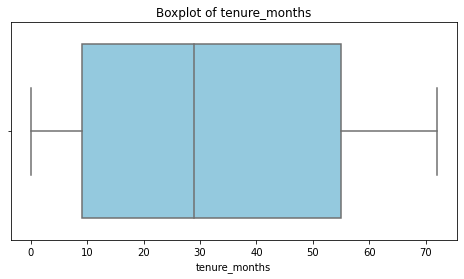

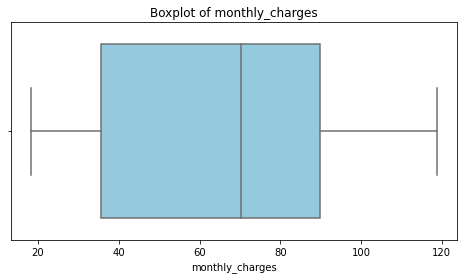

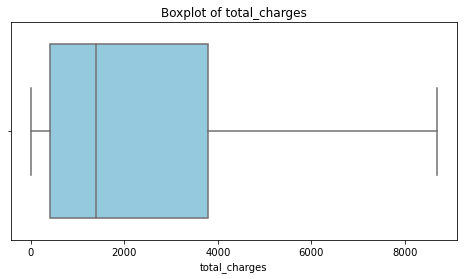

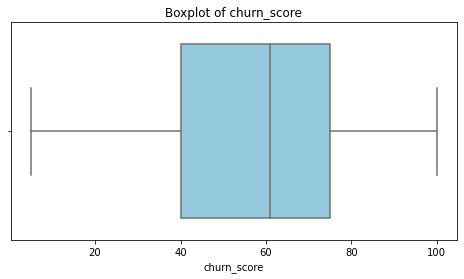

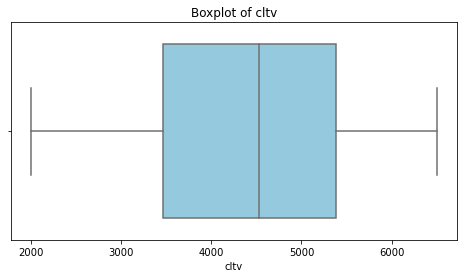

In [36]:
# Boxplot for selected numeric variables
outliers_cols = ["tenure_months", "monthly_charges", "total_charges", "churn_score", "cltv"]
for col in outliers_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color = "skyblue")
    plt.title(f"Boxplot of {col}")
    plt.show()

#### Summary:
The boxplots do not reveal any significant outliers across the selected numerical variables. While some variables exhibit moderate skewness, the observed values remain within the expected ranges based on the IQR method.

### 8.3 IQR Method ( Statistical Confirmation)

In [37]:
# Caculate IQR bounds for outliers_cols
iqr_summary = []

for col in outliers_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    iqr_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outliers_count": outliers_count
    })
iqr_summary_df = pd.DataFrame(iqr_summary) 
iqr_summary_df 

,column,Q1,Q3,IQR,lower_bound,upper_bound,outliers_count
0,tenure_months,9.00,55.00,46.00,-60.000,124.000,0
1,monthly_charges,35.50,89.85,54.35,-46.025,171.375,0
2,total_charges,398.55,3786.60,3388.05,-4683.525,8868.675,0
3,churn_score,40.00,75.00,35.00,-12.500,127.500,0
4,cltv,3469.00,5380.50,1911.50,601.750,8247.750,0


### Summary:

The IQR analysis confirmed the findings from the boxplot assessment, with no outliers detected across the selected numerical variables. As a result, no outlier treatment is required, and all observations will be retained for subsequent analysis and modeling.

# 9. EDA 

This section explores the cleaned dataset to identify key patterns, relationships, and customer churn trends. Additional features are created where appropriate to support business insights and predictive modeling.

### 9.1 Customer Churn Overview

In [38]:
# Display churn distribution
df["churn_label"].value_counts()

No     5174
Yes    1869
Name: churn_label, dtype: int64

In [39]:
# Caculate churn percentage
churn_percentage = (
    df["churn_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
churn_percentage

No     73.46
Yes    26.54
Name: churn_label, dtype: float64

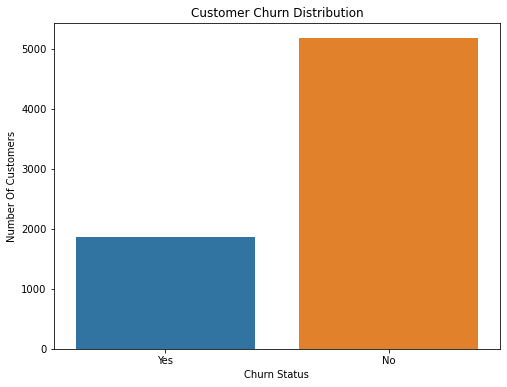

In [40]:
# Plot churn distribution
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="churn_label", order=["Yes", "No"])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number Of Customers")
plt.show()

### Interpretation:

Approximately **26.5%** of customers have churned, indicating that customer retention is an important business challenge. Further analysis will explore the factors associated with customer churn.

### 9.2 Contract Type and Customer Churn

This section examines the relationship between contract type and customer churn to determine whether customer commitment is associated with retention.

#### 9.2.1 Distribution of Contract Types

In [41]:
# Display contract distribution
df["contract"].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: contract, dtype: int64

In [42]:
# Calculate contract percentage
contract_percentage = (
    df["contract"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
contract_percentage

Month-to-month    55.02
Two year          24.07
One year          20.91
Name: contract, dtype: float64

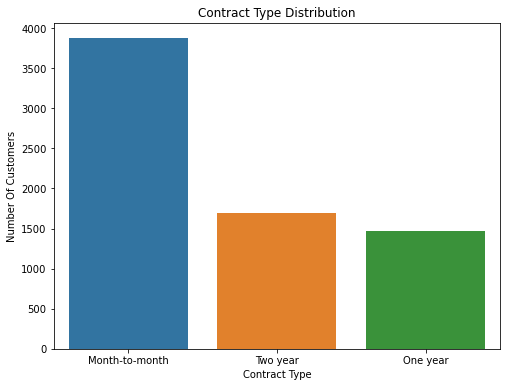

In [43]:
# Plot contract distribution
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="contract", order=df["contract"].value_counts().index)
plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number Of Customers")
plt.show()

#### Interpretation:
The distribution shows that month-to-month contracts are the most common, accounting for approximately 55% of all customers. One-year and two-year contracts are less prevalent. The relationship between contract type and customer churn is examined in the following section.

#### 9.2.2 Contract Type and Customer churn

In [44]:
# Caculate churn rate by contract type
contract_churn =pd.crosstab(df["contract"], df["churn_label"], normalize="index").mul(100).round(3)
contract_churn

churn_label,No,Yes
contract,,
Month-to-month,57.290,42.710
One year,88.730,11.270
Two year,97.168,2.832


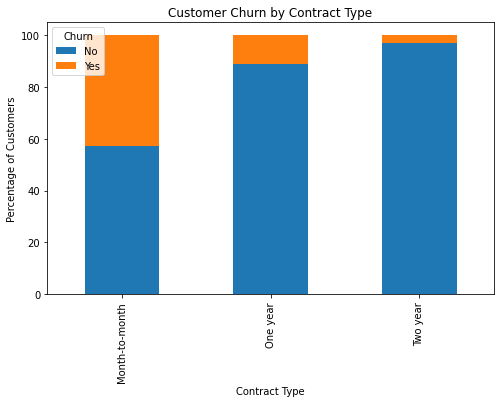

In [45]:
# Plot churn rate by contract type
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")
plt.show()

#### Summary:
Customers with month-to-month contracts exhibit the highest churn rate (42.7%), while customers with one-year and two-year contracts have substantially lower churn rates of 11.3% and 2.8%, respectively. This suggests that longer-term contracts are associated with stronger customer retention.

### 9.3 Tenure and Customer churn
This section explores the distribution of customer tenure and examines its relationship with customer churn. The objective is to determine whether the length of a customer's relationship with the company is associated with customer retention.

#### 9.3.1 Distribution of Customer Tenure

In [46]:
# Display summary statistics for tenure_months
df["tenure_months"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_months, dtype: float64

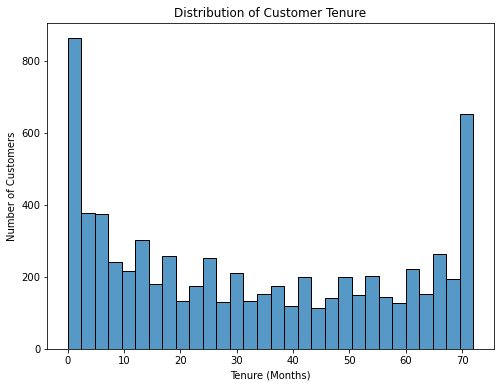

In [47]:
# Plot tenure_months distribution
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="tenure_months", bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation:
The distribution of customer tenure is not uniform, with noticeable concentrations of customers at both the beginning and the end of the tenure range. A relatively large number of customers are either new subscribers or long-term customers, while fewer customers fall within the intermediate tenure periods.

### 9.3.2 Tenure and customer Churn

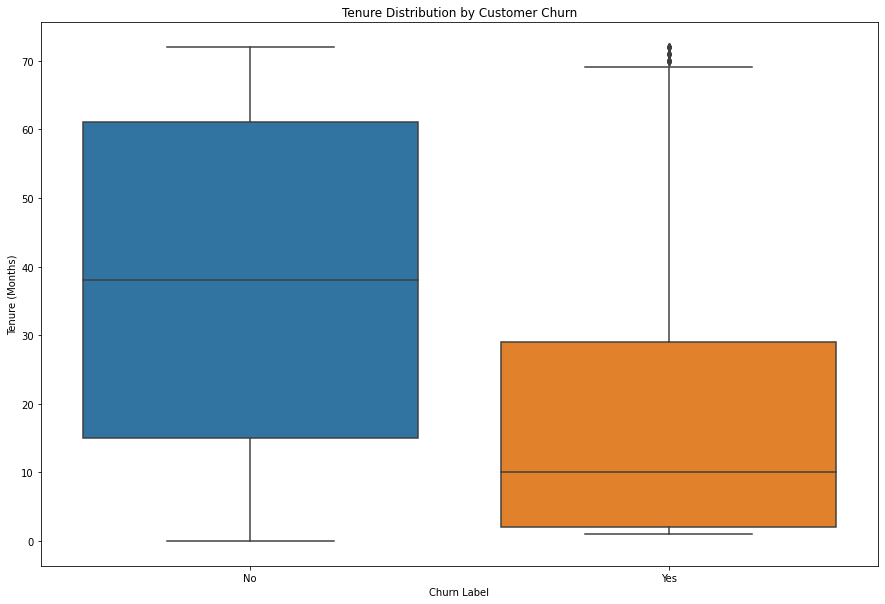

In [48]:
# Plot tenure by customer churn 
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="churn_label", y="tenure_months")
plt.title("Tenure Distribution by Customer Churn")
plt.xlabel("Churn Label")
plt.ylabel("Tenure (Months)")
plt.show()

#### Interpretation:
Customers who churned generally have much shorter tenure than those who remained with the company. The median tenure is substantially lower for churned customers, suggesting that customers are more likely to leave during the early stages of their relationship with the company.

### 9.4 Monthly Charges and Customer Churn

#### 9.4.1 Distribution of Monthly Charges

In [49]:
# Review distribution of monthly_charges
df["monthly_charges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

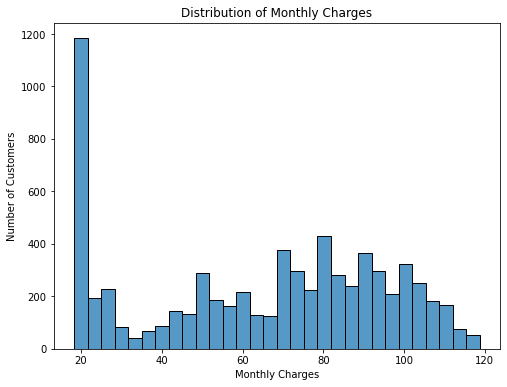

In [50]:
# Plot monthly_charges distribution
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="monthly_charges", bins=30)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation:
The distribution of monthly charges is not uniform. A large concentration of customers pays relatively low monthly charges, while the remaining customers are distributed across higher monthly charge levels.

#### 9.4.2 Monthly charges and Customer Churn

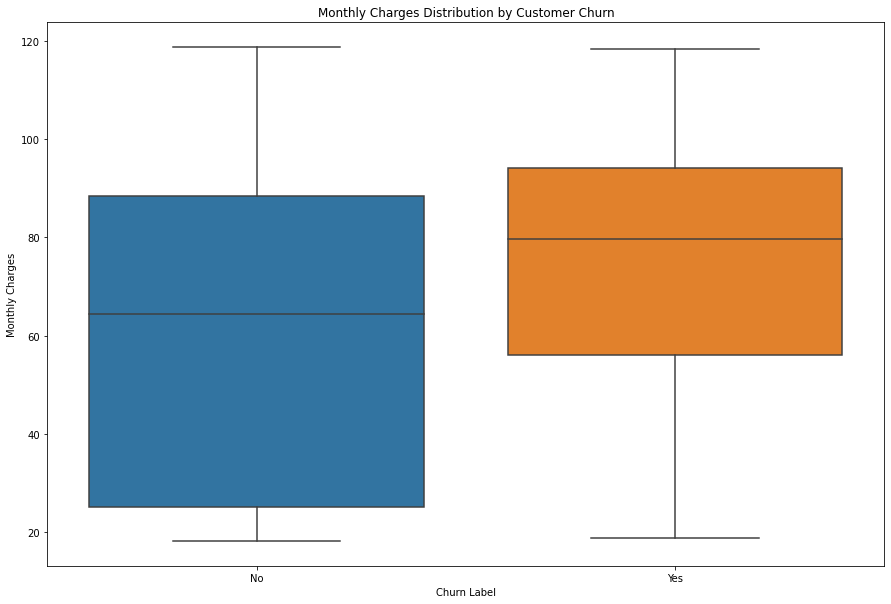

In [51]:
# Plot tenure by customer churn 
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="churn_label", y="monthly_charges")
plt.title("Monthly Charges Distribution by Customer Churn")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charges")
plt.show()

#### Interpretation:
Customers who churned generally have higher monthly charges than those who remained with the company. The higher median monthly charges among churned customers suggest that customers with more expensive monthly plans may be more likely to leave.

### 9.5 Total Charges and Customer Churn

#### 9.5.1 Distribution Of Total Charges

In [52]:
# Review distribution of Total Charges
df["total_charges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: total_charges, dtype: float64

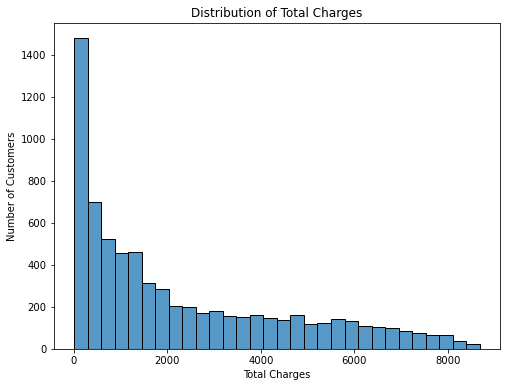

In [53]:
# Plot total charges distribution
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="total_charges", bins=30)
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

The distribution of total charges is highly right-skewed rather than normally distributed. Most customers have relatively low total charges, while the number of customers decreases as total charges increase.

### 9.5.2 Total Charges and Customer Churn

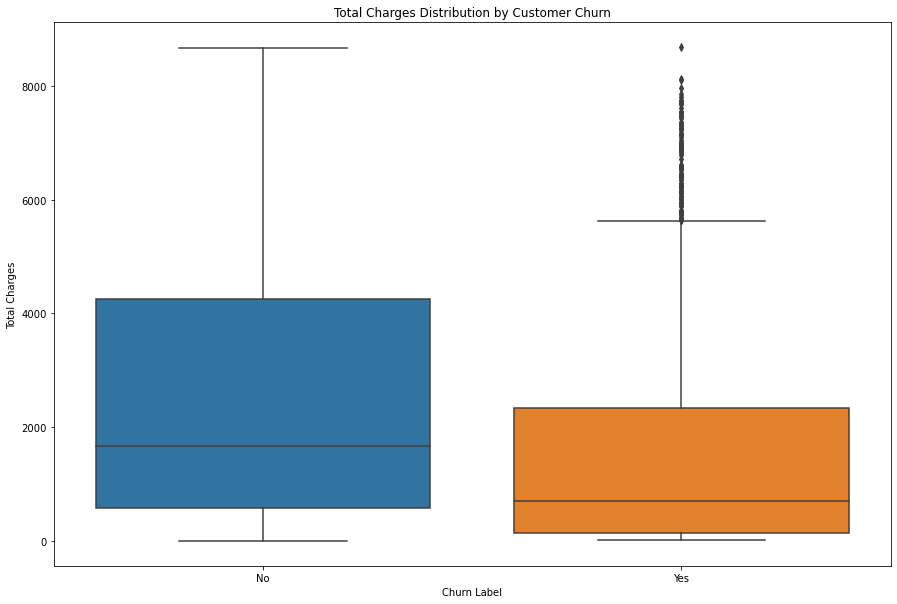

In [54]:
# Plot total charges by customer churn
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="churn_label", y="total_charges")
plt.title("Total Charges Distribution by Customer Churn")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges") 
plt.show()

#### Interpretation:
Customers who remained with the company generally have higher total charges than those who churned. The higher median total charges among retained customers suggest that customers with longer relationships tend to contribute more to the company's total revenue.

### 9.6 Service Features and Customer Churn
This section examines the relationship between key service-related features and customer churn to identify which services are associated with higher customer retention.

#### 9.6.1 Internet Service

In [55]:
# Distribution of Internet Service
df["internet_service"].value_counts(normalize=True).mul(100).round(2)

Fiber optic    43.96
DSL            34.37
No             21.67
Name: internet_service, dtype: float64

In [56]:
# Caculate churn rate by internet service
internet_churn = pd.crosstab(df["internet_service"], df["churn_label"], normalize="index").mul(100).round(3)
internet_churn

churn_label,No,Yes
internet_service,,
DSL,81.041,18.959
Fiber optic,58.107,41.893
No,92.595,7.405


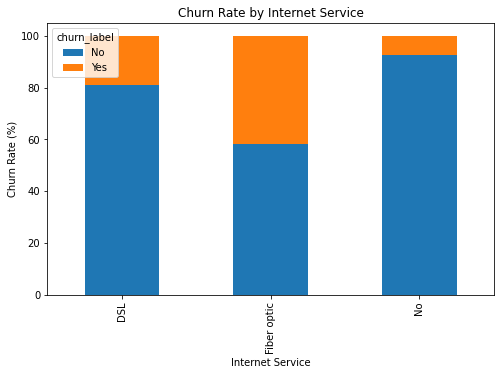

In [57]:
# Plot churn rate by internet service
internet_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.6.2 Online Security

In [58]:
# Distribution of online_security
df["online_security"].value_counts(normalize=True).mul(100).round(2)

No                     49.67
Yes                    28.67
No internet service    21.67
Name: online_security, dtype: float64

In [59]:
# Caculate churn rate by online_security
online_security_churn = pd.crosstab(df["online_security"], df["churn_label"], normalize="index").mul(100).round(3)
online_security_churn

churn_label,No,Yes
online_security,,
No,58.233,41.767
No internet service,92.595,7.405
Yes,85.389,14.611


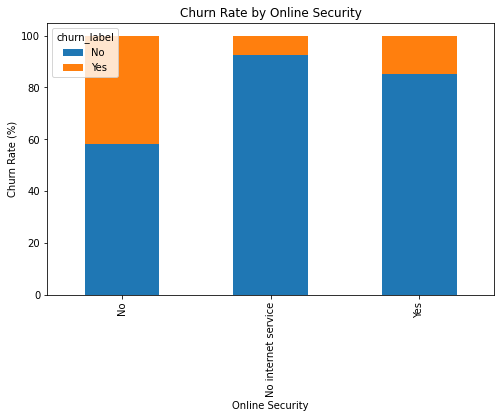

In [60]:
# Plot churn rate by online_security
online_security_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.6.3 Tech support

In [61]:
# Distribution of tech_support
df["tech_support"].value_counts(normalize=True).mul(100).round(2)

No                     49.31
Yes                    29.02
No internet service    21.67
Name: tech_support, dtype: float64

In [62]:
# caculate churn rate by tech_support
tech_support_churn = pd.crosstab(df["tech_support"], df["churn_label"], normalize="index").mul(100).round(3)
tech_support_churn

churn_label,No,Yes
tech_support,,
No,58.365,41.635
No internet service,92.595,7.405
Yes,84.834,15.166


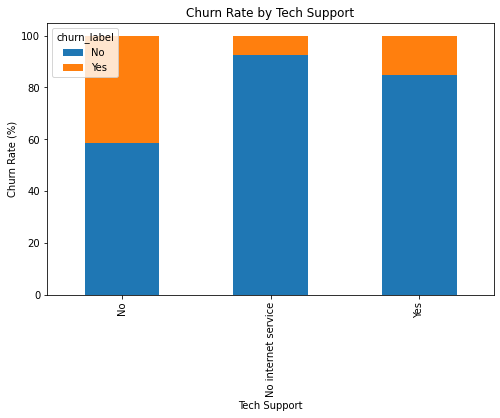

In [63]:
# Plot churn rate by tech_support
tech_support_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.6.4 Online Backup

In [64]:
# Distribution of online_backup
df["online_backup"].value_counts(normalize=True).mul(100).round(2)

No                     43.84
Yes                    34.49
No internet service    21.67
Name: online_backup, dtype: float64

In [65]:
# Caculate churn rate by online_backup
online_backup_churn = pd.crosstab(df["online_backup"], df["churn_label"], normalize="index").mul(100).round(3)
online_backup_churn

churn_label,No,Yes
online_backup,,
No,60.071,39.929
No internet service,92.595,7.405
Yes,78.469,21.531


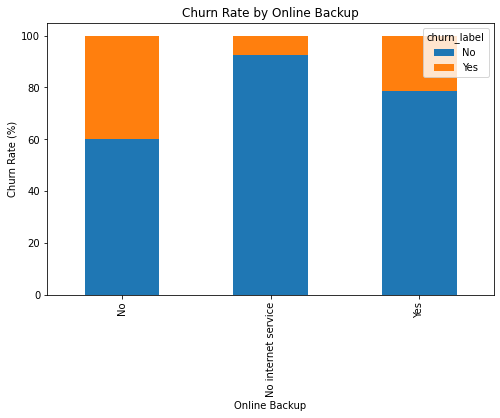

In [66]:
# Plot churn rate by online_backup
online_backup_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.6.5 Device Protection

In [67]:
# Distribution of device_protection
df["device_protection"].value_counts(normalize=True).mul(100).round(2)

No                     43.94
Yes                    34.39
No internet service    21.67
Name: device_protection, dtype: float64

In [68]:
# Caculate churn rate by device_protection
device_protection_churn = pd.crosstab(df["device_protection"], df["churn_label"], normalize="index").mul(100).round(3)
device_protection_churn

churn_label,No,Yes
device_protection,,
No,60.872,39.128
No internet service,92.595,7.405
Yes,77.498,22.502


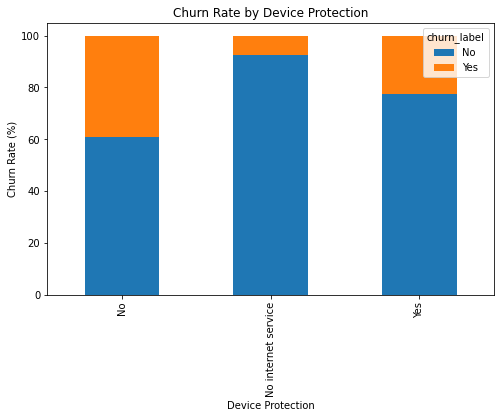

In [69]:
# Plot churn rate by device_protection
device_protection_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.6.6 Streaming TV

In [70]:
# Distribution of streaming_tv
df["streaming_tv"].value_counts(normalize=True).mul(100).round(2)

No                     39.90
Yes                    38.44
No internet service    21.67
Name: streaming_tv, dtype: float64

In [71]:
# Caculate churn rate by streaming_tv
streaming_tv_churn = pd.crosstab(df["streaming_tv"], df["churn_label"], normalize="index").mul(100).round(3)
streaming_tv_churn

churn_label,No,Yes
streaming_tv,,
No,66.477,33.523
No internet service,92.595,7.405
Yes,69.930,30.070


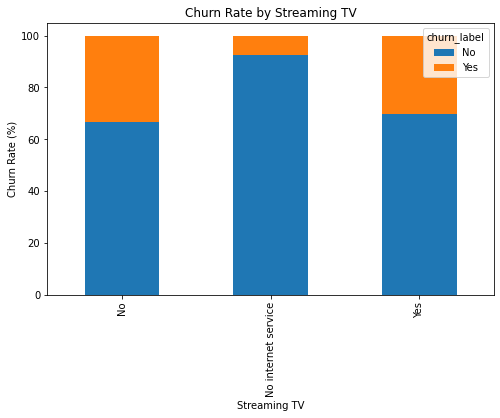

In [72]:
# Plot churn rate by straming_tv
streaming_tv_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.6.7 Streaming Movies

In [73]:
# Distribution of streaming_movies
df["streaming_movies"].value_counts(normalize=True).mul(100).round(2)

No                     39.54
Yes                    38.79
No internet service    21.67
Name: streaming_movies, dtype: float64

In [74]:
# Caculate churn rate by streaming_movies
streaming_movies_churn = pd.crosstab(df["streaming_movies"], df["churn_label"], normalize="index").mul(100).round(3)
streaming_movies_churn

churn_label,No,Yes
streaming_movies,,
No,66.320,33.680
No internet service,92.595,7.405
Yes,70.059,29.941


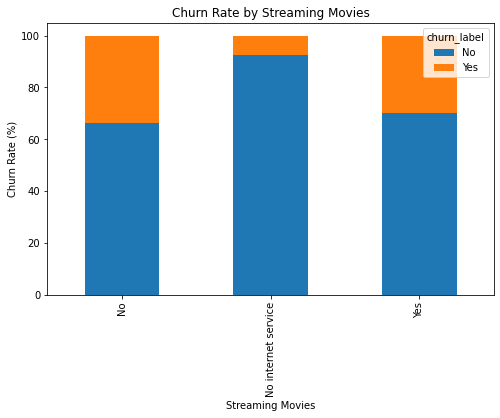

In [75]:
# Plot churn rate by streaming_movies
streaming_movies_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.show()

#### Interpretation:
Service features show different levels of association with customer churn. Security- and support-related services, such as Online Security and Tech Support, are associated with substantially lower churn rates. Online Backup and Device Protection also contribute to improved customer retention, although their effects are less pronounced. In contrast, entertainment-related services, including Streaming TV and Streaming Movies, exhibit only a weak relationship with customer churn. Overall, customers appear to value reliability and support services more than entertainment features when deciding whether to remain with the company.

### 9.7 Payment and Billing Features
In this section, we examine how payment and billing characteristics are associated with customer churn. Understanding these patterns may help identify billing-related factors that influence customer retention.

#### 9.7.1 Payment Method

In [76]:
# Distribution of payment_method
df["payment_method"].value_counts(normalize=True).mul(100).round(2)

Electronic check             33.58
Mailed check                 22.89
Bank transfer (automatic)    21.92
Credit card (automatic)      21.61
Name: payment_method, dtype: float64

In [77]:
# Caculate churn rate by payment_method
payment_method_churn = pd.crosstab(df["payment_method"], df["churn_label"], normalize="index").mul(100).round(3)
payment_method_churn

churn_label,No,Yes
payment_method,,
Bank transfer (automatic),83.290,16.710
Credit card (automatic),84.757,15.243
Electronic check,54.715,45.285
Mailed check,80.893,19.107


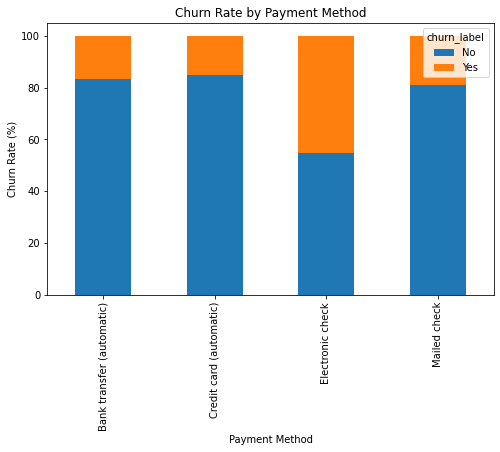

In [78]:
# Plot churn rate by payment_method
payment_method_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.show()

#### 9.7.2 Paperless Billing

In [79]:
# Distribution of paperless_billing
df["paperless_billing"].value_counts(normalize=True).mul(100).round(2)

Yes    59.22
No     40.78
Name: paperless_billing, dtype: float64

In [80]:
# Caculate churn rate by paperless_billing
paperless_billing_churn = pd.crosstab(df["paperless_billing"], df["churn_label"], normalize="index").mul(100).round(3)
paperless_billing_churn

churn_label,No,Yes
paperless_billing,,
No,83.670,16.330
Yes,66.435,33.565


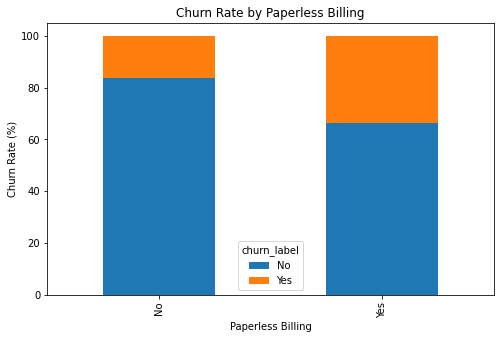

In [81]:
# Plot churn rate by paperless_billing
paperless_billing_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.show()

#### Interpretation:
Payment and billing characteristics show a meaningful association with customer churn. Customers using Electronic check exhibit substantially higher churn rates than those using automatic payment methods, while customers enrolled in Paperless Billing also demonstrate higher churn rates. These findings suggest that billing preferences may serve as useful indicators for identifying customers at greater risk of churn.

### 9.8 Demographic Features
In this section, we examine whether demographic characteristics are associated with customer churn. Understanding these relationships may help identify customer segments with different retention patterns.

#### 9.8.1 Gender

In [82]:
# Distribution of gender
df["gender"].value_counts(normalize=True).mul(100).round(2)

Male      50.48
Female    49.52
Name: gender, dtype: float64

In [83]:
# Calculate churn rate by gender
gender_churn = pd.crosstab(df["gender"], df["churn_label"], normalize="index").mul(100).round(3)
gender_churn

churn_label,No,Yes
gender,,
Female,73.079,26.921
Male,73.840,26.160


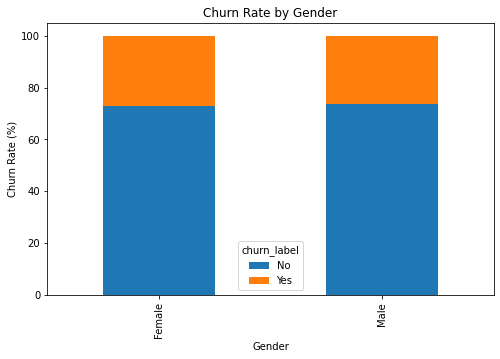

In [84]:
# Plot churn rate by gender
gender_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.show()

#### 9.8.2 Senior Citizen

In [85]:
# Distribution of senior_citizen
df["senior_citizen"].value_counts(normalize=True).mul(100).round(2)

No     83.79
Yes    16.21
Name: senior_citizen, dtype: float64

In [86]:
# Caculate churn rate by senior_citizen
senior_citizen_churn = pd.crosstab(df["senior_citizen"], df["churn_label"], normalize="index").mul(100).round(3)
senior_citizen_churn

churn_label,No,Yes
senior_citizen,,
No,76.394,23.606
Yes,58.319,41.681


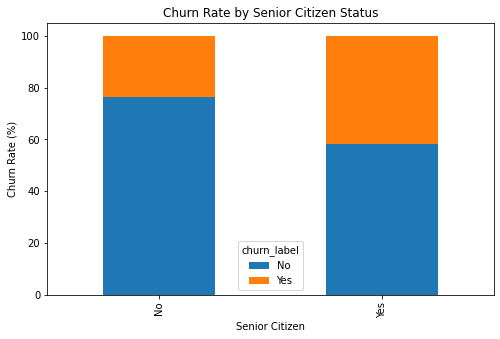

In [87]:
# Plot churn rate by senior_citizen
senior_citizen_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.8.3 Partner

In [88]:
# Distribution of partner
df["partner"].value_counts(normalize=True).mul(100).round(2)

No     51.7
Yes    48.3
Name: partner, dtype: float64

In [89]:
# Caculate churn rate by partner
partner_churn = pd.crosstab(df["partner"], df["churn_label"], normalize="index").mul(100).round(3)
partner_churn

churn_label,No,Yes
partner,,
No,67.042,32.958
Yes,80.335,19.665


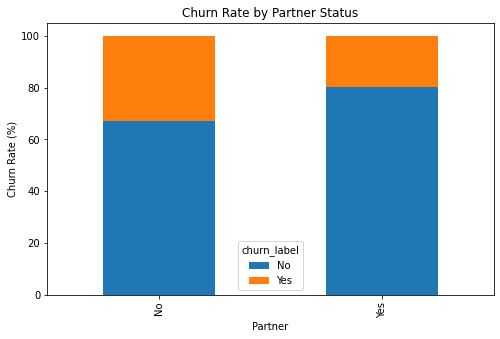

In [90]:
# Plot churn rate by partner
partner_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.show()  

#### 9.8.4 Dependents

In [91]:
# Distribution of dependents
df["dependents"].value_counts(normalize=True).mul(100).round(2)

No     76.9
Yes    23.1
Name: dependents, dtype: float64

In [92]:
# Caculate churn rate by dependents
dependents_churn = pd.crosstab(df["dependents"], df["churn_label"], normalize="index").mul(100).round(3)
dependents_churn

churn_label,No,Yes
dependents,,
No,67.448,32.552
Yes,93.485,6.515


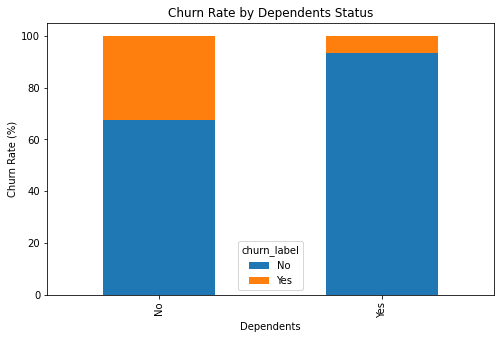

In [93]:
# Plot churn rate by dependents
dependents_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.show()

#### Interpretation:
Demographic characteristics exhibit varying levels of association with customer churn. While **Gender** shows little relationship with churn, **Senior Citizen**, **Partner**, and **Dependents** demonstrate more noticeable differences, suggesting that household and family-related characteristics may help identify customers at higher risk of churn.

### 9.9 Phone Features
In this section, we examine whether phone-related service features are associated with customer churn. Understanding these relationships may help identify whether customers’ phone service usage influences retention.

#### 9.9.1 Phone Service

In [94]:
# Distribution of phone_service
df["phone_service"].value_counts(normalize=True).mul(100).round(2)  

Yes    90.32
No      9.68
Name: phone_service, dtype: float64

In [95]:
# Caculate churn rate by phone_service
phone_service_churn = pd.crosstab(df["phone_service"], df["churn_label"], normalize="index").mul(100).round(3)
phone_service_churn 

churn_label,No,Yes
phone_service,,
No,75.073,24.927
Yes,73.290,26.710


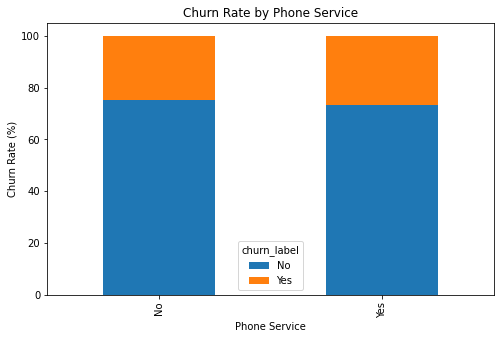

In [96]:
# Plot churn rate by phone_service
phone_service_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.show()

#### 9.9.2 Multiple Lines

In [97]:
# Distribution of multiple_lines
df["multiple_lines"].value_counts(normalize=True).mul(100).round(2)

No                  48.13
Yes                 42.18
No phone service     9.68
Name: multiple_lines, dtype: float64

In [98]:
# Caculate churn rate by multiple_lines
multiple_lines_churn = pd.crosstab(df["multiple_lines"], df["churn_label"], normalize="index").mul(100).round(3)
multiple_lines_churn

churn_label,No,Yes
multiple_lines,,
No,74.956,25.044
No phone service,75.073,24.927
Yes,71.390,28.610


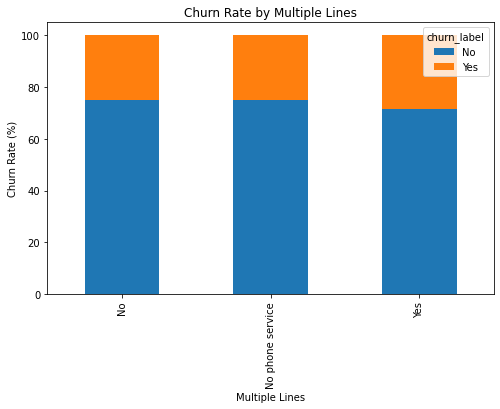

In [99]:
# Plot churn rate by multiple_lines
multiple_lines_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Churn Rate (%)")
plt.show()

#### Interpretation:
Phone-related features exhibit only a weak association with customer churn. While customers with multiple phone lines show a slightly higher churn rate, phone service characteristics appear to have a relatively limited impact on customer retention compared with other factors analyzed in this study.

### EDA Summary:
The exploratory analysis identified several factors associated with customer churn. *Contract type*, *tenure*, *monthly charges*, *internet-related services*, *payment* and *billing* features, and selected *demographic characteristics* exhibited meaningful relationships with churn, while *Gender* and *phone-related* features showed relatively weak associations. These findings provide valuable business insights and establish a strong foundation for feature engineering and predictive modeling.

## 10. Feature Engineering
In this section, the dataset is prepared for predictive modeling by selecting relevant features and applying the necessary transformations. These steps ensure that the data is suitable for building reliable and interpretable machine learning models.

In [100]:
# Display columns names
df.columns

Index(['customer_id', 'city', 'zip_code', 'latitude', 'longitude', 'gender',
       'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_label',
       'churn_value', 'churn_score', 'cltv', 'churn_reason'],
      dtype='object')

### 10.1 Feature Selection
In this step, non-predictive variables that do not contribute to customer churn prediction are removed from the dataset. Identifier and geographic features are excluded because they are not relevant to the business objectives or predictive modeling.

In [101]:
# Check churn_label and churn_value relationship
pd.crosstab(df["churn_label"], df["churn_value"])

churn_value,0,1
churn_label,,
No,5174,0
Yes,0,1869


`churn_value` duplicates the target variable and is removed to prevent data leakage.

In [102]:
# Drop columns that are not relevant for churn analysis
columns_to_drop = [
    "customer_id", 
    "city", 
    "zip_code",
    "latitude", 
    "longitude", 
    "churn_reason", 
    "churn_score", 
    "cltv", 
    "churn_value"
]
df.drop(columns = columns_to_drop, inplace=True)


In [103]:
# Check columns after dropping irrelevant columns
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_label'],
      dtype='object')

### 10.2 Separate Feaures and Target

In [104]:
# Separate features and target variable
X = df.drop(columns = "churn_label")
y = df["churn_label"]

In [105]:
# Display features and matrix shape
X.shape

(7043, 19)

In [106]:
# display target vector shape
y.shape

(7043,)

The dataset has been successfully separated into predictor features (X) and the target variable (y). The feature matrix contains all variables available for prediction, while the target variable represents customer churn status. This separation prepares the data for preprocessing and model development.

### 10.3 Encode Target Variable

In [107]:
# Encode target variable 
y = y.map({"Yes": 1, "No": 0})

In [108]:
# Verify target encoding
pd.crosstab(df["churn_label"], y)

churn_label,0,1
churn_label,,
No,5174,0
Yes,0,1869


### 10.4 Identify Categorical and Numerical Columns


In [109]:
# Identify categorical and numeric columns
categori_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
numeri_cols = X.select_dtypes(include=np.number).columns.tolist()

In [110]:
# Display categorical features
categori_cols

['gender',
 'senior_citizen',
 'partner',
 'dependents',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method']

In [111]:
# display numeric features
numeri_cols

['tenure_months', 'monthly_charges', 'total_charges']

The predictor variables were grouped into categorical and numerical feature sets to support subsequent preprocessing. Categorical variables will be prepared for One-Hot Encoding, while numerical variables will remain in their original form unless feature scaling is required by the selected machine learning algorithm.

### 10.5 Train/Test Split
The dataset is divided into training and testing subsets to evaluate model performance on unseen data. This separation helps assess how well the model generalizes beyond the data used for training.

In [112]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Why use stratify=y?**

Stratified sampling preserves the original class distribution of the target variable across the training and testing sets, resulting in a more representative data split and a more reliable evaluation of model performance.

### 10.6 One-Hot Encoding

In [113]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [114]:
# Create one-hot encoder
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

In [115]:
# Fit encoder on training data and transform categorical features
X_train_encoded = encoder.fit_transform(X_train[categori_cols])

In [116]:
# Transform testing categorical features
X_test_encoded = encoder.transform(X_test[categori_cols])

In [117]:
# Get encoded feature names
encoded_feature_names = encoder.get_feature_names_out(categori_cols)
encoded_feature_names

array(['gender_Male', 'senior_citizen_Yes', 'partner_Yes',
       'dependents_Yes', 'phone_service_Yes',
       'multiple_lines_No phone service', 'multiple_lines_Yes',
       'internet_service_Fiber optic', 'internet_service_No',
       'online_security_No internet service', 'online_security_Yes',
       'online_backup_No internet service', 'online_backup_Yes',
       'device_protection_No internet service', 'device_protection_Yes',
       'tech_support_No internet service', 'tech_support_Yes',
       'streaming_tv_No internet service', 'streaming_tv_Yes',
       'streaming_movies_No internet service', 'streaming_movies_Yes',
       'contract_One year', 'contract_Two year', 'paperless_billing_Yes',
       'payment_method_Credit card (automatic)',
       'payment_method_Electronic check', 'payment_method_Mailed check'],
      dtype=object)

In [118]:
# Convert encoded training data to DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

In [119]:
# Conver encoded testing data to DataFrame
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

In [120]:
# Combine numerical and encoded categorical features
X_train_final = pd.concat([X_train[numeri_cols], X_train_encoded], axis=1)
X_test_final = pd.concat([X_test[numeri_cols], X_test_encoded], axis=1)


In [121]:
# Display final feature matrix shapes
print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)

X_train_final: (5634, 30)
X_test_final : (1409, 30)


In [122]:
# Preserve unscaled feautures for later use
X_train_unscaled = X_train_final.copy()
X_test_unscaled = X_test_final.copy()

### 10.7 Feature Scaling

Feature scaling is considered before model training because some classification algorithms, such as Logistic Regression, are sensitive to differences in feature scale. Since the baseline model will use Logistic Regression, numerical features are scaled using the training data and the same transformation is applied to the testing data.

In [123]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

In [124]:
# Create scaler
scaler = StandardScaler()

In [125]:
# Scale training numerical features
X_train_final[numeri_cols] = scaler.fit_transform(X_train_final[numeri_cols])

In [126]:
# Scale testing numerical features
X_test_final[numeri_cols] = scaler.transform(X_test_final[numeri_cols])

In [127]:
# Review scaled training data
X_train_final[numeri_cols].describe().round(2)

,tenure_months,monthly_charges,total_charges
count,5634.00,5634.00,5634.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.32,-1.54,-1.01
25%,-0.96,-0.97,-0.83
50%,-0.14,0.18,-0.40
75%,0.92,0.83,0.67
max,1.61,1.79,2.80


#### Interpretation:
The numerical features were successfully standardized using the training data statistics. Standardizing the features ensures that variables measured on different scales contribute equally during model training while preventing information leakage from the testing dataset.

## 11. Classification Modeling

### 11.1 Logistic Regression (Baseline Model)
Logistic Regression was selected as the baseline classification model due to its simplicity, interpretability, and strong performance on binary classification problems. Establishing a baseline provides a meaningful benchmark for evaluating more complex models later in the analysis.

In [128]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_final, y_train)

LogisticRegression(random_state=42)

In [129]:
# Generate predictions on the test set
y_pred = log_reg.predict(X_test_final)

# Predict churn probabilities for the test set
y_pred_proba = log_reg.predict_proba(X_test_final)[:, 1]

In [130]:
# Import evaluation metrics
from sklearn.metrics import (accuracy_score, 
                             precision_score,
                             recall_score,
                             f1_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_curve,
                             auc
)


In [131]:
# evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.8020
Precision : 0.6435
Recall : 0.5695
F1-Score : 0.6043


In [132]:
# Display classification report
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



#### Interpretation:
The Logistic Regression model achieved an overall accuracy of 80%, meaning it correctly classified about 80% of the customers in the test set. The model performed better at identifying non-churn customers than churn customers. For customers predicted as churn, 64% actually churned (Precision = 0.64), while the model successfully identified 57% of all actual churn customers (Recall = 0.57). Overall, the baseline model provides a reasonable starting point, but its ability to detect churn customers can still be improved.

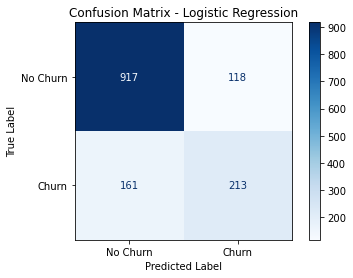

In [133]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**Confusion Matrix Interpretation**

- **True Negative (TN = 917):** Customers who did not actually *churn* and were correctly predicted as *No Churn*.
- **False Positive (FP = 118):** Customers who did not actually *churn* but were incorrectly predicted as *Churn*.
- **False Negative (FN = 161):** Customers who actually *churned* but were incorrectly predicted as *No Churn*.
- **True Positive (TP = 213):** Customers who actually *churned* and were correctly predicted as *Churn*.

Reducing `False Negatives` is particularly important in churn prediction because these customers actually churn but are mistakenly predicted as non-churn, causing the business to miss valuable retention opportunities.

In [134]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

AUC Score: 0.8490


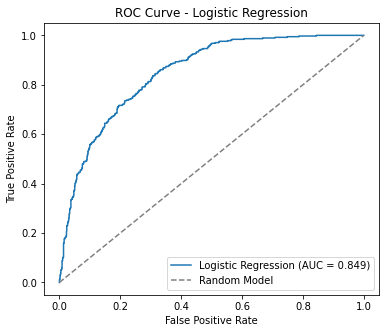

In [135]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.show()

#### Interpretation:
The model achieved an AUC score of 0.849, which means it can distinguish churn customers from non-churn customers quite well. The ROC curve is clearly above the random baseline, showing that the model has good predictive ability. Although the performance is satisfactory for a baseline model, it can likely be improved by testing more advanced classification algorithms.

In [136]:
# Check training and testing accuracy
train_accuracy = log_reg.score(X_train_final, y_train)
test_accuracy = log_reg.score(X_test_final, y_test)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Testing Accuracy: {test_accuracy:.3f}")

Training Accuracy: 0.814
Testing Accuracy: 0.802


The training and testing accuracies are very close (81.4% vs. 80.2%), indicating that the Logistic Regression model generalizes well and does not show signs of overfitting.

### 11.2 Decision Tree
A Decision Tree classifier is trained to predict customer churn. The model is evaluated using the same metrics as the baseline Logistic Regression model.

In [137]:
# Train Decision Tree Classifiemodel
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_unscaled, y_train)


DecisionTreeClassifier(random_state=42)

In [138]:
# Generate predictions on the test set
y_pred_dt= decision_tree.predict(X_test_unscaled)

# Predict churn probabilities for the test set
y_pred_proba_dt = decision_tree.predict_proba(X_test_unscaled)[:, 1]

In [139]:
# Evaluate model performance
accuracy_dt = accuracy_score(y_test,y_pred_dt)
precision_dt = precision_score(y_test,y_pred_dt)
recall_dt = recall_score(y_test,y_pred_dt)
f1_dt = f1_score(y_test,y_pred_dt)

print(f"Decision Tree Classifier Performance:")
print(f"Accuracy_dt:{accuracy_dt:.4f}")
print(f"Precision_dt:{precision_dt:.4f}")
print(f"Recall_dt:{recall_dt:.4f}")
print(f"F1_dt:{f1_dt:.4f}")

Decision Tree Classifier Performance:
Accuracy_dt:0.7282
Precision_dt:0.4875
Recall_dt:0.4679
F1_dt:0.4775


In [140]:
# Display classification report
print(classification_report(y_test, y_pred_dt, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.81      0.82      0.82      1035
       Churn       0.49      0.47      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.73      1409



##### Interpretation:
The Decision Tree model performs considerably better at identifying non-churn customers than churn customers. While the model achieves strong performance for the No Churn class, its recall and F1-score for the Churn class remain relatively low, indicating that many customers at risk of churning are not correctly identified.

Since the primary business objective is to detect potential churn customers for retention efforts, the current Decision Tree model does not provide satisfactory predictive performance.

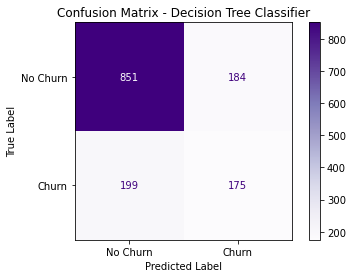

In [141]:
# Generate confusion matrix for Decision Tree Classifier
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["No Churn", "Churn"])
disp_dt.plot(cmap="Purples", values_format="d")

plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**Confusion Matrix Interpretation**

- **True Negative (TN = 851):** Customers who did not actually *churn* and were correctly predicted as *No Churn*.
- **False Positive (FP = 184):** Customers who did not actually *churn* but were incorrectly predicted as *Churn*.
- **False Negative (FN = 199):** Customers who actually *churned* but were incorrectly predicted as *No Churn*.
- **True Positive (TP = 175):** Customers who actually *churned* and were correctly predicted as *Churn*.

Reducing `False Negatives` is particularly important in churn prediction because these customers actually churn but are mistakenly predicted as non-churn, causing the business to miss valuable retention opportunities.

In [142]:
# Calculate ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)

# Calculate AUC score
roc_auc_dt = auc(fpr_dt, tpr_dt)

print(f"AUC Score: {roc_auc_dt:.4f}")

AUC Score: 0.6446


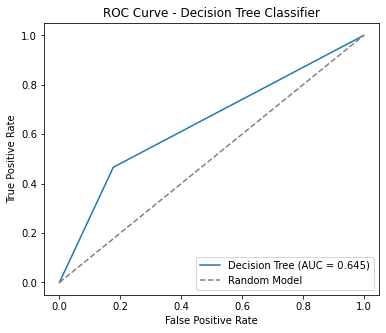

In [143]:
plt.figure(figsize=(6,5))

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend(loc="lower right")

plt.show()

##### Interpretation:

The Decision Tree model achieved an AUC score of 0.645, indicating limited ability to distinguish between churn and non-churn customers. Although the model performs better than random guessing, its discriminative performance is considerably weaker than the baseline Logistic Regression model.

In [144]:
# Check training and testing accuracy
train_accuracy_dt = decision_tree.score(X_train_unscaled, y_train)
test_accuracy_dt = decision_tree.score(X_test_unscaled, y_test)

print(f"Training Accuracy: {train_accuracy_dt:.3f}")
print(f"Testing Accuracy: {test_accuracy_dt:.3f}")

Training Accuracy: 0.998
Testing Accuracy: 0.728


##### Interpretation:

The Decision Tree achieved a training accuracy of 99.8% but only 72.8% on the test set. This substantial performance gap indicates that the model has overfitted the training data, memorizing training patterns rather than learning generalizable relationships. As a result, its predictive performance on unseen data is limited.

#### 11.2.1 Decision Tree Hyperparameter Tuning

The baseline Decision Tree showed signs of overfitting. To improve generalization, GridSearchCV is used to search for the best combination of key hyperparameters.

- **max_depth:** Controls the maximum depth of the tree.
- **min_samples_split:** Minimum samples required to split a node.
- **min_samples_leaf:** Minimum samples required in each leaf node.

In [145]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [146]:
# Define hyperparameter grid for Decision Tree Classifier
param_grid_dt = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"]
}

In [147]:
# Configure GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)


In [148]:
# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train_unscaled, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 10, 20]},
             scoring='f1', verbose=1)

In [149]:
# Best Hyperparameters
best_params_dt = grid_search_dt.best_params_
print("Best Hyperparameters for Decision Tree Classifier:")
print(best_params_dt)

Best Hyperparameters for Decision Tree Classifier:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [150]:
# Best F1 Score
best_f1_score_dt = grid_search_dt.best_score_
print(f"Best F1 Score from GridSearchCV: {best_f1_score_dt:.4f}")


Best F1 Score from GridSearchCV: 0.5908


In [151]:
# Store tuned Decision Tree 
decision_tree_tuned = grid_search_dt.best_estimator_

In [152]:
# Generate tuned predictions on the test set
y_pred_dt_tuned = decision_tree_tuned.predict(X_test_unscaled)

# Generate tuned churn probabilities for the test set
y_pred_proba_dt_tuned = decision_tree_tuned.predict_proba(X_test_unscaled)[:, 1]

In [153]:
# Evaluate tuned model performance
accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
precision_dt_tuned = precision_score(y_test, y_pred_dt_tuned)
recall_dt_tuned = recall_score(y_test, y_pred_dt_tuned)
f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned)

print(f"Tuned Decision Tree Classifier Performance:")
print(f"Accuracy_dt_tuned: {accuracy_dt_tuned:.4f}")
print(f"Precision_dt_tuned: {precision_dt_tuned:.4f}")
print(f"Recall_dt_tuned: {recall_dt_tuned:.4f}")
print(f"F1_dt_tuned: {f1_dt_tuned:.4f}")

Tuned Decision Tree Classifier Performance:
Accuracy_dt_tuned: 0.7984
Precision_dt_tuned: 0.6541
Recall_dt_tuned: 0.5107
F1_dt_tuned: 0.5736


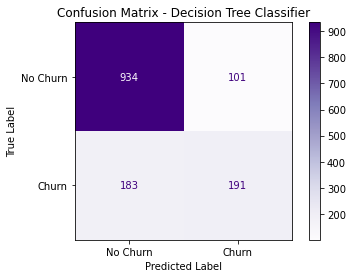

In [154]:
# Generate confusion matrix for tuned Decision Tree Classifier
cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)

disp_dt_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_dt_tuned, display_labels=["No Churn", "Churn"])
disp_dt_tuned.plot(cmap="Purples", values_format="d")

plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**Confusion Matrix Interpretation**

- **True Negative (TN = 934):** Customers who did not actually *churn* and were correctly predicted as *No Churn*.
- **False Positive (FP = 101):** Customers who did not actually *churn* but were incorrectly predicted as *Churn*.
- **False Negative (FN = 183):** Customers who actually *churned* but were incorrectly predicted as *No Churn*.
- **True Positive (TP = 191):** Customers who actually *churned* and were correctly predicted as *Churn*.

The tuned Decision Tree reduced both `False Positives` and `False Negatives` compared with the baseline model. It correctly identified more churn customers while also improving predictions for non-churn customers, indicating a more balanced classification performance.

In [155]:
# Calculate ROC curve
fpr_dt_tuned, tpr_dt_tuned, thresholds_dt_tuned = roc_curve(y_test, y_pred_proba_dt_tuned)

# Calculate AUC score
roc_auc_dt_tuned = auc(fpr_dt_tuned, tpr_dt_tuned)

print(f"AUC Score: {roc_auc_dt_tuned:.4f}")

AUC Score: 0.8356


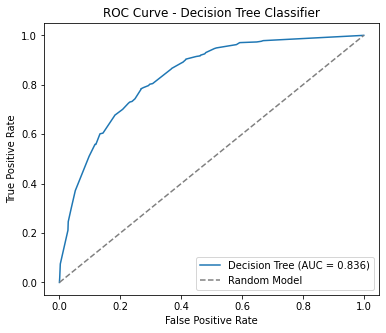

In [156]:
plt.figure(figsize=(6,5))

plt.plot(fpr_dt_tuned, tpr_dt_tuned, label=f"Decision Tree (AUC = {roc_auc_dt_tuned:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend(loc="lower right")

plt.show()

#### Interpretation:
The tuned Decision Tree achieved an `AUC score` of **0.836**, representing a substantial improvement over the baseline model. The ROC curve indicates that the tuned model has a strong ability to distinguish churn customers from non-churn customers, demonstrating that hyperparameter tuning significantly improved its classification performance.

In [157]:
# Check training and testing accuracy
train_accuracy_dt_tuned = decision_tree_tuned.score(X_train_unscaled, y_train)
test_accuracy_dt_tuned = decision_tree_tuned.score(X_test_unscaled, y_test)

print(f"Training Accuracy: {train_accuracy_dt_tuned:.3f}")
print(f"Testing Accuracy: {test_accuracy_dt_tuned:.3f}")

Training Accuracy: 0.812
Testing Accuracy: 0.798


#### Interpretation:
The tuned Decision Tree achieved similar training (81.2%) and testing (79.8%) accuracy. The small gap between them indicates that overfitting was significantly reduced, resulting in better generalization to unseen data.

### 11.3 Random Forest
A Random Forest classifier is trained to improve churn prediction by combining multiple Decision Trees. Its performance is evaluated against Logistic Regression and the tuned Decision Tree.

In [158]:
# Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_unscaled, y_train)

RandomForestClassifier(random_state=42)

In [159]:
# Generate predictions on the test set
y_pred_rf = random_forest.predict(X_test_unscaled)

# Generate churn probabilities for the test set
y_pred_proba_rf = random_forest.predict_proba(X_test_unscaled)[:, 1]

In [160]:
# Evaluate Random Forest model performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Classifier Performance:")
print(f"Accuracy_rf:{accuracy_rf:.4f}")
print(f"Precision_rf:{precision_rf:.4f}")
print(f"Recall_rf:{recall_rf:.4f}")
print(f"F1-Score_rf:{f1_rf:.4f}")

Random Forest Classifier Performance:
Accuracy_rf:0.7928
Precision_rf:0.6314
Recall_rf:0.5267
F1-Score_rf:0.5743


##### Interpretation:
The Random Forest model achieved better performance than the baseline Decision Tree. Its higher precision, recall, and F1-score indicate better identification of churn customers with more balanced overall performance.

In [161]:
# Dispaly classification report
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



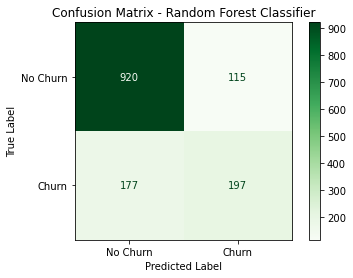

In [162]:
# Generate Confusion Matrix for Random Forest Classifier
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Churn", "Churn"])
disp_rf.plot(cmap="Greens", values_format="d")

plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Confusion Matrix Interpretation**

- **True Negative (TN = 920):** Customers who did not actually *churn* and were correctly predicted as *No Churn*.
- **False Positive (FP = 115):** Customers who did not actually *churn* but were incorrectly predicted as *Churn*.
- **False Negative (FN = 177):** Customers who actually *churned* but were incorrectly predicted as *No Churn*.
- **True Positive (TP = 197):** Customers who actually *churned* and were correctly predicted as *Churn*.

The Random Forest model identified more churn customers by reducing `False Negatives` and increasing `True Positives`. This improvement came with a slight increase in `False Positives`.

In [163]:
# Calculate Roc Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

# Calculate AUC score
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(f"AUC Score: {roc_auc_rf:.4f}")

AUC Score: 0.8327


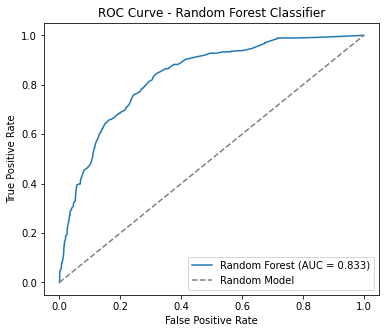

In [164]:
plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend(loc="lower right")
plt.show()

##### Interpretation:
The Random Forest model achieved an `AUC score` of **0.833**, indicating a strong ability to distinguish between churn and non-churn customers. The ROC curve demonstrates good classification performance.

In [165]:
# Check training and testing accuracy
train_accuracy_rf = random_forest.score(X_train_unscaled, y_train)
test_accuracy_rf = random_forest.score(X_test_unscaled, y_test)

print(f"Training Accuracy: {train_accuracy_rf:.3f}")
print(f"Testing Accuracy: {test_accuracy_rf:.3f}")

Training Accuracy: 0.998
Testing Accuracy: 0.793


##### Interpretation:
The Random Forest achieved a training accuracy of 99.9% and a testing accuracy of 79.9%, indicating that the model still suffers from overfitting. However, it generalizes better than the baseline Decision Tree by achieving higher performance on unseen data.

#### 11.3.1 Random Forest Hyperparameter Tuning
The baseline Random Forest showed signs of overfitting. GridSearchCV is used to identify a better combination of hyperparameters and improve generalization.

- **n_estimators:** Number of Decision Trees in the forest.
- **max_depth:** Maximum depth of each tree.
- **min_samples_split:** Minimum samples required to split a node.
- **min_samples_leaf:** Minimum samples required in each leaf node.
- **max_features:** Number of features considered at each split.

In [166]:
# Define hyperparameter grid for Random Forest Classifier
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"],
}

In [167]:
# Configure GridSearchCV for Random Forest Classifier
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [168]:
# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_unscaled, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)

In [169]:
# Best hyperparameters from GridSearchCV
best_params_rf = grid_search_rf.best_params_
print("Best Hyperparameters for Random Forest Classifier:")
print(best_params_rf)

Best Hyperparameters for Random Forest Classifier:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [170]:
# Best F1 Score from GridSearchCV
best_f1_score_rf = grid_search_rf.best_score_
print(f"Best F1 Score from GridSearchCV: {best_f1_score_rf:.4f}")

Best F1 Score from GridSearchCV: 0.5932


In [171]:
# Store tuned Random Forest Classifier
random_forest_tuned = grid_search_rf.best_estimator_

In [172]:
# Generate tuned predictions on the test set
y_pred_rf_tuned = random_forest_tuned.predict(X_test_unscaled)  

# generate tuned churn probabilities for the test set
y_pred_proba_rf_tuned = random_forest_tuned.predict_proba(X_test_unscaled)[:, 1]

In [173]:
# Evaluate tuned Random Forest model performance
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest Classifier Performance:")
print(f"Accuracy_rf_tuned: {accuracy_rf_tuned:.4f}")
print(f"Precision_rf_tuned: {precision_rf_tuned:.4f}")
print(f"Recall_rf_tuned: {recall_rf_tuned:.4f}")
print(f"F1_rf_tuned: {f1_rf_tuned:.4f}")

Tuned Random Forest Classifier Performance:
Accuracy_rf_tuned: 0.8091
Precision_rf_tuned: 0.6733
Recall_rf_tuned: 0.5455
F1_rf_tuned: 0.6027


##### Interpretation:
The tuned Random Forest improved accuracy, precision, recall, and F1-score compared with the baseline model, indicating better overall performance and more effective churn prediction.

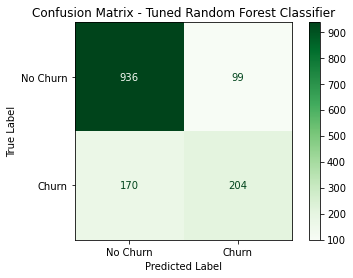

In [174]:
# Generate Confusion Matrix for tuned Random Forest Classifier
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=["No Churn", "Churn"])
disp_rf_tuned.plot(cmap="Greens", values_format="d")

plt.title("Confusion Matrix - Tuned Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Confusion Matrix Interpretation**

- **True Negative (TN = 936):** Customers who did not actually *churn* and were correctly predicted as *No Churn*.
- **False Positive (FP = 99):** Customers who did not actually *churn* but were incorrectly predicted as *Churn*.
- **False Negative (FN = 170):** Customers who actually *churned* but were incorrectly predicted as *No Churn*.
- **True Positive (TP = 204):** Customers who actually *churned* and were correctly predicted as *Churn*.

The tuned Random Forest reduced both `False Positives` and `False Negatives` while increasing `True Positive` and `True Negative` compared with the baseline model. It correctly identified more churn customers while also improving predictions for non-churn customers, indicating a more balanced classification performance.

In [175]:
# Calculate ROC curve for tuned Random Forest Classifier
fpr_rf_tuned, tpr_rf_tuned, thresholds_rf_tuned = roc_curve(y_test, y_pred_proba_rf_tuned)

# Calculate AUC score for tuned Random Forest Classifier
roc_auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)
print(f"AUC Score: {roc_auc_rf_tuned:.4f}")

AUC Score: 0.8517


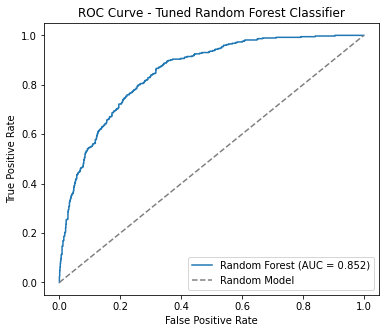

In [176]:
plt.figure(figsize=(6,5))

plt.plot(fpr_rf_tuned, tpr_rf_tuned, label=f"Random Forest (AUC = {roc_auc_rf_tuned:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest Classifier")
plt.legend(loc="lower right")
plt.show()

##### Interpretation:
The tuned Random Forest slightly improved the AUC score from 0.833 to 0.852, indicating a modest improvement in classification performance.

In [177]:
# Check training and testing accuracy for tuned Random Forest Classifier
train_accuracy_rf_tuned = random_forest_tuned.score(X_train_unscaled, y_train)
test_accuracy_rf_tuned = random_forest_tuned.score(X_test_unscaled, y_test)

print(f"Training Accuracy: {train_accuracy_rf_tuned:.3f}")
print(f"Testing Accuracy: {test_accuracy_rf_tuned:.3f}")

Training Accuracy: 0.869
Testing Accuracy: 0.809


##### Interpretation:
The tuned Random Forest substantially reduced overfitting. The gap between training accuracy (86.9%) and testing accuracy (80.9%) is much smaller, indicating improved generalization on unseen data.

#### 11.4 XGBoost
**XGBoost** is a boosting algorithm that builds Decision Trees sequentially, with each tree correcting the errors of the previous one.

In [178]:
# Install XGBoost package
!pip install xgboost

You should consider upgrading via the '/Users/farnazgoli/opt/anaconda3/bin/python -m pip install --upgrade pip' command.


In [179]:
# Train XGBoost Classifier
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_unscaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [180]:
# Generate predictions on the test set
y_pred_xgb = xgb.predict(X_test_unscaled)

# Generate churn probabilities for the test set
y_pred_proba_xgb = xgb.predict_proba(X_test_unscaled)[:, 1]

In [181]:
# Evaluate XGBoost model performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Classifier Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")

XGBoost Classifier Performance:
Accuracy: 0.7828
Precision: 0.6056
Recall: 0.5214
F1-Score: 0.5603


In [182]:
# Display classification report for XGBoost Classifier
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



##### Interpretation:
The baseline XGBoost model achieved an accuracy of 78%. It performed better at identifying non-churn customers than churn customers. Overall, the model provides reasonable performance, but hyperparameter tuning may further improve its ability to detect churn customers.

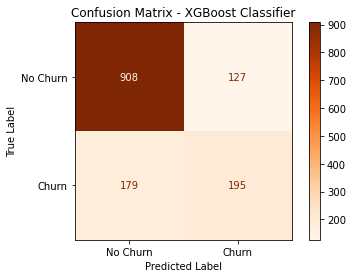

In [183]:
# Generate Confusion Matrix for XGBoost Classifier
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["No Churn", "Churn"])
disp_xgb.plot(cmap="Oranges", values_format="d")

plt.title("Confusion Matrix - XGBoost Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Confusion Matrix Interpretation**

- **True Negative (TN = 908):** Customers who did not actually *churn* and were correctly predicted as *No Churn*.
- **False Positive (FP = 127):** Customers who did not actually *churn* but were incorrectly predicted as *Churn*.
- **False Negative (FN = 179):** Customers who actually *churned* but were incorrectly predicted as *No Churn*.
- **True Positive (TP = 195):** Customers who actually *churned* and were correctly predicted as *Churn*.

The confusion matrix shows that the XGBoost model correctly classified most non-churn customers (TN = 908). However, it still missed a considerable number of churn customers (FN = 179), indicating that the model has room for improvement in identifying churn cases.

In [184]:
# Calculate ROC curve for tuned XGBoost Classifier
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)

# Calculate AUC score for tuned XGBoost Classifier
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
print(f"AUC Score: {roc_auc_xgb:.4f}")

AUC Score: 0.8359


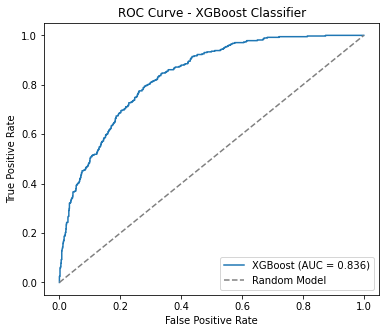

In [185]:
plt.figure(figsize=(6,5))

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Model") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Classifier")
plt.legend(loc="lower right")
plt.show()

##### Interpretation:

The ROC curve shows that the XGBoost model performs well in distinguishing churn and non-churn customers. An AUC score of 0.836 indicates good classification performance.

In [186]:
# Check training and testing accuracy for XGBoost Classifier 
train_accuracy_xgb = xgb.score(X_train_unscaled, y_train)
test_accuracy_xgb = xgb.score(X_test_unscaled, y_test)

print(f"Training Accuracy: {train_accuracy_xgb:.4f}")
print(f"Testing Accuracy: {test_accuracy_xgb:.4f}")

Training Accuracy: 0.9341
Testing Accuracy: 0.7828


The baseline XGBoost model shows signs of overfitting. The training accuracy (93.4%) is considerably higher than the testing accuracy (78.3%), indicating that the model does not generalize well to unseen data.

#### 11.4.1 XGBoost Hyperparameter Tuning

The baseline XGBoost model showed signs of overfitting. GridSearchCV is used to identify a better combination of hyperparameters and improve generalization.

- **n_estimators:** Number of boosting trees.
- **learning_rate:** Controls how much each tree contributes to the model.
- **max_depth:** Maximum depth of each tree.
- **subsample:** Fraction of training samples used to build each tree.
- **colsample_bytree:** Fraction of features used to build each tree.

In [187]:
# Define hyperparameter grid for XGBoost Classifier
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

In [188]:
# Configure GridSearchCV for XGBoost Classifier  
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [189]:
# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train_unscaled, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [190]:
# Display best hyperparameters from GridSearchCV for XGBoost Classifier
best_params_xgb = grid_search_xgb.best_params_
print("Best Hyperparameters for XGBoost Classifier:")
print(best_params_xgb)

Best Hyperparameters for XGBoost Classifier:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [191]:
# Display F1 Score from GridSearchCV for XGBoost Classifier
best_f1_score_xgb = grid_search_xgb.best_score_
print(f"Best F1 Score from GridSearchCV: {best_f1_score_xgb:.4f}")


Best F1 Score from GridSearchCV: 0.6146


In [192]:
# Store tuned XGBoost Classifier
xgb_tuned = grid_search_xgb.best_estimator_

In [193]:
# Generate tuned predictions on the test set for XGBoost Classifier
y_pred_xgb_tuned = xgb_tuned.predict(X_test_unscaled)

# Generate tuned churn probabilities for the test set for XGBoost Classifier
y_pred_proba_xgb_tuned = xgb_tuned.predict_proba(X_test_unscaled)[:, 1]

In [194]:
# Evaluate tuned XGBoost model performance
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)

print(f"Tuned XGBoost Classifier Performance:")
print(f"Accuracy: {accuracy_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall: {recall_xgb_tuned:.4f}")
print(f"F1-Score: {f1_xgb_tuned:.4f}")

Tuned XGBoost Classifier Performance:
Accuracy: 0.8105
Precision: 0.6698
Recall: 0.5642
F1-Score: 0.6125


Hyperparameter tuning improved the XGBoost model performance. The tuned model achieved higher Accuracy, Precision, Recall, and F1-score, indicating better classification and improved generalization.

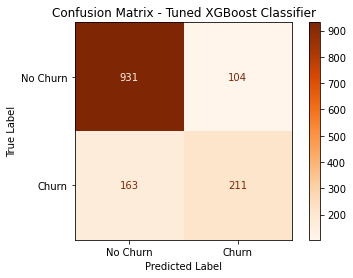

In [195]:
# Generate Confusion Matrix for Tuned XGBoost Classifier
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

disp_xgb_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_tuned, display_labels=["No Churn", "Churn"])
disp_xgb_tuned.plot(cmap="Oranges", values_format="d")

plt.title("Confusion Matrix - Tuned XGBoost Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Confusion Matrix Interpretation**

- **True Negative (TN = 931):** Customers who did not actually *churn* and were correctly predicted as *No Churn*.
- **False Positive (FP = 104):** Customers who did not actually *churn* but were incorrectly predicted as *Churn*.
- **False Negative (FN = 163):** Customers who actually *churned* but were incorrectly predicted as *No Churn*.
- **True Positive (TP = 211):** Customers who actually *churned* and were correctly predicted as *Churn*.

The confusion matrix shows that the tuned XGBoost model correctly classified most non-churn customers (TN = 931). It also identified more churn customers (TP = 211) while reducing false positives and false negatives, indicating improved classification performance.

In [196]:
# Calculate ROC curve for Tuned XGBoost Classifier
fpr_xgb_tuned, tpr_xgb_tuned, thresholds_xgb_tuned = roc_curve(y_test, y_pred_proba_xgb_tuned)

# Calculate AUC score for Tuned XGBoost Classifier
roc_auc_xgb_tuned = auc(fpr_xgb_tuned, tpr_xgb_tuned)
print(f"AUC Score: {roc_auc_xgb_tuned:.4f}")

AUC Score: 0.8544


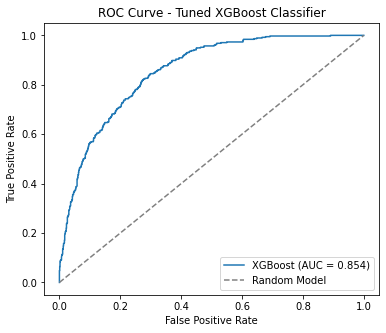

In [197]:
plt.figure(figsize=(6,5))

plt.plot(fpr_xgb_tuned, tpr_xgb_tuned, label=f"XGBoost (AUC = {roc_auc_xgb_tuned:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost Classifier")
plt.legend(loc="lower right")
plt.show()

##### Interpretation:
The ROC curve shows that the tuned XGBoost model has good discrimination between churn and non-churn customers. The AUC score improved from 0.836 to 0.854, indicating better classification performance after hyperparameter tuning.

In [198]:
# Check training and testing accuracy for Tuned XGBoost Classifier
train_accuracy_xgb_tuned = xgb_tuned.score(X_train_unscaled, y_train)
test_accuracy_xgb_tuned = xgb_tuned.score(X_test_unscaled, y_test) 

print(f"Training Accuracy: {train_accuracy_xgb_tuned:.4f}")
print(f"Testing Accuracy: {test_accuracy_xgb_tuned:.4f}")

Training Accuracy: 0.8294
Testing Accuracy: 0.8105


The tuned XGBoost model substantially reduced overfitting. The small gap between training accuracy (82.9%) and testing accuracy (81.1%) indicates improved generalization on unseen data.

### 12. Model Comparison
This section compares the performance of all classification models based on Accuracy, Precision, Recall, F1-score, AUC, and generalization performance to identify the best model for customer churn prediction.

In [199]:
# Create a dataframe to summarize model performance metrics
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Tuned Decision Tree",
              "Random Forest", "Tuned Random Forest", "XGBoost", "Tuned XGBoost"],
    "Accuracy": [accuracy, accuracy_dt, accuracy_dt_tuned,
                 accuracy_rf, accuracy_rf_tuned, accuracy_xgb, accuracy_xgb_tuned],
    "Precision": [precision, precision_dt, precision_dt_tuned,
                  precision_rf, precision_rf_tuned, precision_xgb, precision_xgb_tuned],
    "Recall": [recall, recall_dt, recall_dt_tuned,
               recall_rf, recall_rf_tuned, recall_xgb, recall_xgb_tuned],
    "F1-Score": [f1, f1_dt, f1_dt_tuned,
                 f1_rf, f1_rf_tuned, f1_xgb, f1_xgb_tuned],
    "AUC": [roc_auc, roc_auc_dt, roc_auc_dt_tuned,
            roc_auc_rf, roc_auc_rf_tuned, roc_auc_xgb, roc_auc_xgb_tuned]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.849004
1,Decision Tree,0.728176,0.487465,0.467914,0.477490,0.644554
2,Tuned Decision Tree,0.798439,0.654110,0.510695,0.573574,0.835604
3,Random Forest,0.792761,0.631410,0.526738,0.574344,0.832659
4,Tuned Random Forest,0.809084,0.673267,0.545455,0.602659,0.851742
5,XGBoost,0.782825,0.605590,0.521390,0.560345,0.835921
6,Tuned XGBoost,0.810504,0.669841,0.564171,0.612482,0.854449


##### **Model Comparison Conclusion:**
The comparison shows that the `tuned XGBoost` model achieved the best overall performance, with the highest Accuracy and AUC score. Hyperparameter tuning improved both Random Forest and XGBoost, while the Decision Tree showed the weakest performance. Therefore, the **tuned XGBoost model** was selected as the final model for customer churn prediction.

### 13. Business Questions

`Business Question 1: Which customer groups are more likely to churn?`

Customers with **month-to-month contracts, shorter tenure**, and **higher monthly charges** were more likely to churn. Customers using **Fiber Optic Internet** also showed a higher churn rate compared to DSL and customers without internet service.

`Business Question 2: How do contract type, tenure, and monthly charges influence customer churn?`

Customers with **month-to-month contracts** were more likely to churn than those with one-year or two-year contracts. Customers with **longer tenure** had lower churn rates, while **higher monthly charges** were associated with a higher likelihood of churn.

`Business Question 3: Which services are most strongly associated with customer retention?`

Customers with **Online Security** and **Tech Support** had the lowest churn rates, indicating that these services are strongly associated with customer retention. **Online Backup** and **Device Protection** were also associated with lower churn rates.`

`Business Question 4: What customer charactristics appear to be the strongest predictors of churn?`

In [200]:
# Feature Importance
feature_importance_df = pd.DataFrame({
    "Feature": X_train_unscaled.columns,
    "Importance": xgb_tuned.feature_importances_
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
feature_importance_df.head(10)

,Feature,Importance
25,contract_Two year,0.198588
10,internet_service_Fiber optic,0.182247
24,contract_One year,0.135654
28,payment_method_Electronic check,0.084255
11,internet_service_No,0.063937
6,dependents_Yes,0.052166
0,tenure_months,0.046966
26,paperless_billing_Yes,0.029044
13,online_security_Yes,0.028019
23,streaming_movies_Yes,0.026764


##### Answer Q.4.
The feature importance analysis from the tuned XGBoost model showed that **contract type**, **internet service type (especially Fiber Optic)**, **payment method**, **tenure**, **paperless billing**, **online security**, and the presence of **dependents** were among the strongest predictors of customer churn.

`Business Question 5: Can customer churn be predicted using machine learning models?`

Yes. Customer churn can be predicted effectively using machine learning models. Among all the models evaluated, the **Tuned XGBoost** model achieved the best overall performance, with the highest accuracy and AUC score, making it the most suitable model for predicting customer churn.

`Business Question 6: What business actions could help reduce customer churn and improve customer retention?`

The company should focus on retaining customers with **month-to-month contracts** by offering incentives to switch to longer-term contracts. Providing or promoting **Online Security** and **Tech Support** services may help reduce churn. Special attention should also be given to customers with **high monthly charges, Fiber Optic Internet,** and **short tenure** through personalized offers, loyalty programs, and proactive customer support.